# Load Libraries & Data


In [1]:
!pip install statsmodels
!pip install ta

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import ta



In [3]:
# # Load the Data
# file_path = "/kaggle/input/egx30-dataset/EGX30_2000-2025.csv"
# df = pd.read_csv(file_path)

In [4]:
# Load the CSV file
file_path = "EGX30_2000-2025.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())
    

       Date      Price       Open       High        Low     Vol. Change %
0  2/6/2025  30,011.84  29,735.59  30,011.84  29,735.59   83.50M    0.93%
1  2/5/2025  29,735.59  29,668.47  29,772.63  29,596.50  103.71M    0.23%
2  2/4/2025  29,668.47  29,754.77  29,937.39  29,668.47  135.05M   -0.29%
3  2/3/2025  29,754.77  29,917.96  30,001.23  29,698.79  152.06M   -0.55%
4  2/2/2025  29,917.96  30,010.62  30,198.22  29,917.96  103.16M   -0.31%


In [5]:
# # Load the CSV file
# file_path = "EGX30_2000-2025.csv"
# df = pd.read_csv(file_path)

# # Display the first few rows
# print(df.head())
    

# Preprocessing


## Initial Data Inspection


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      6106 non-null   object
 1   Price     6106 non-null   object
 2   Open      6106 non-null   object
 3   High      6106 non-null   object
 4   Low       6106 non-null   object
 5   Vol.      3906 non-null   object
 6   Change %  6106 non-null   object
dtypes: object(7)
memory usage: 334.0+ KB


**Date:** The trading date of the EGX30 index (formatted as MM/DD/YYYY).

**Price:** The closing price of the EGX30 index on that particular day.

**Open:** The opening price of the EGX30 index at the start of the trading session.

**High:** The highest price the EGX30 index reached during the trading session.

**Low:** The lowest price the EGX30 index reached during the trading session.

**Vol. (Volume):** The total number of shares traded during that day.

**Change %:** The percentage change in the EGX30 index compared to the previous trading day's closing price.


In [7]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())


Missing Values:
 Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2200
Change %       0
dtype: int64


In [8]:
# Check for duplicates
print("Number of Duplicates:", df.duplicated().sum())

Number of Duplicates: 0


## Data Cleaning


In [9]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
# Convert numerical columns by removing commas and converting to float
cols_to_convert = ['Price', 'Open', 'High', 'Low']
df[cols_to_convert] = df[cols_to_convert].replace(',', '', regex=True).astype(float)

In [11]:
# Convert Change % column (remove '%' and convert to decimal)
df['Change %'] = df['Change %'].str.replace('%', '', regex=True).astype(float) / 100

In [12]:
def convert_vol(value):
    if isinstance(value, str):  # Ensure value is a string
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        elif 'B' in value:
            return float(value.replace('B', '')) * 1_000_000_000
        else:
            return float(value)  # Convert numbers stored as strings
    return value  # Return original if already float or NaN

df['Vol.'] = df['Vol.'].apply(convert_vol)

In [13]:
df.dropna(inplace=True)

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3906 entries, 0 to 3932
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3906 non-null   datetime64[ns]
 1   Price     3906 non-null   float64       
 2   Open      3906 non-null   float64       
 3   High      3906 non-null   float64       
 4   Low       3906 non-null   float64       
 5   Vol.      3906 non-null   float64       
 6   Change %  3906 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 244.1 KB
None


## Detect Outliers


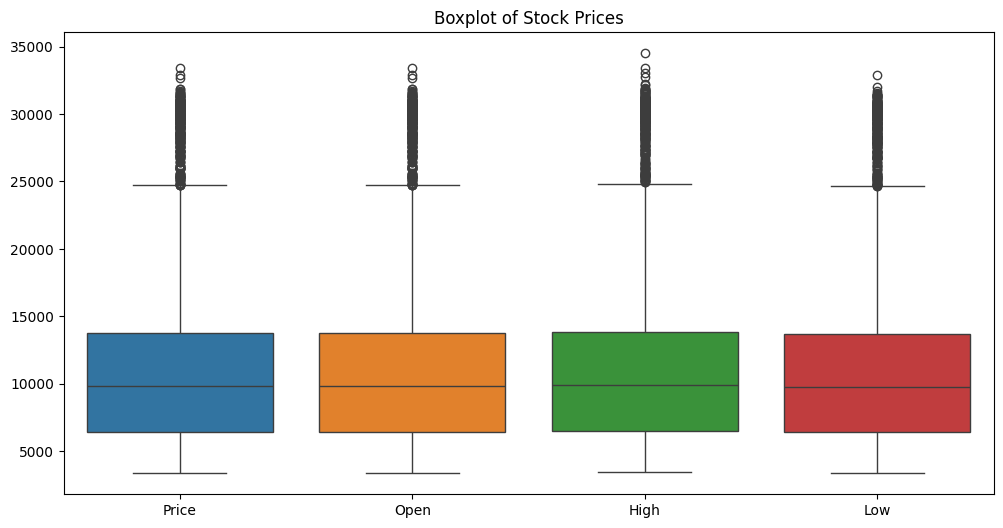

Price    282
Open     281
High     287
Low      277
dtype: int64

In [15]:
# Plot boxplots to detect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["Price", "Open", "High", "Low"]])
plt.title("Boxplot of Stock Prices")
plt.show()

# Check for statistical outliers using IQR
Q1 = df[["Price", "Open", "High", "Low"]].quantile(0.25)
Q3 = df[["Price", "Open", "High", "Low"]].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[["Price", "Open", "High", "Low"]] < (Q1 - 1.5 * IQR)) | 
            (df[["Price", "Open", "High", "Low"]] > (Q3 + 1.5 * IQR))).sum()

outliers

In [16]:
outlier_condition = (df[["Price", "Open", "High", "Low"]] < (Q1 - 1.5 * IQR)) | (df[["Price", "Open", "High", "Low"]] > (Q3 + 1.5 * IQR))
outliers_df = df[outlier_condition.any(axis=1)]

# Display the first few rows of detected outliers
outliers_df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.0093
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.0023
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.0029
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.0055
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.0031
5,2025-01-30,30010.62,29891.61,30127.35,29891.61,127580000.0,0.0040
6,2025-01-29,29891.61,29646.60,29982.32,29646.60,112710000.0,0.0083
7,2025-01-28,29646.60,29742.12,29900.15,29646.60,63280000.0,-0.0032
8,2025-01-27,29742.12,30034.85,30091.04,29726.66,90870000.0,-0.0097
9,2025-01-26,30034.85,29997.69,30276.52,29995.30,76040000.0,0.0012


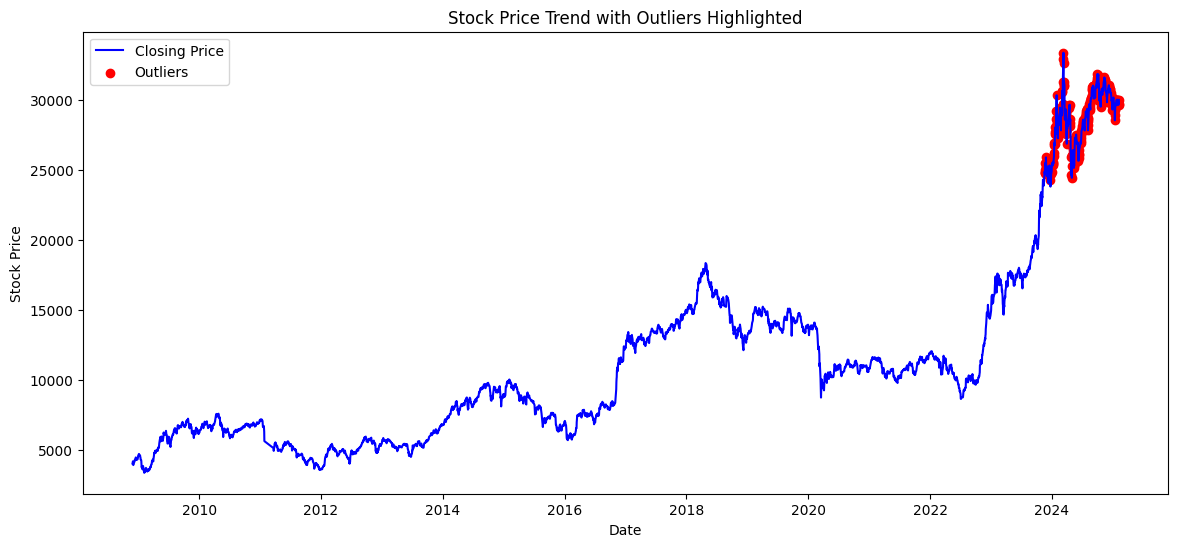

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Price"], label="Closing Price", color="blue")
plt.scatter(outliers_df["Date"], outliers_df["Price"], color="red", label="Outliers")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Trend with Outliers Highlighted")
plt.legend()
plt.show()

During **2023 and 2024** , Egypt experienced significant economic events and policy changes that likely influenced stock prices:

**Economic Events**

- Inflation Surge: Annual inflation rates reached a peak of 38% in September 2023, before easing to 24% in January 2025.
  ([TRADINGECONOMICS.COM](https://tradingeconomics.com/egypt/inflation-cpi))

- GDP Growth Decline: The real GDP growth rate slowed to 2.4% in the fourth quarter of the fiscal year 2023/2024, down from 3.8% the previous year.
  ([MPED.GOV.EG](https://mped.gov.eg/singlenews?id=5718&lang=en&utm_source=chatgpt.com))

**Government Policies**

- Minimum Wage Increase: In February 2025, the government announced a raise in the monthly minimum wage for public sector workers to 7,000 Egyptian pounds, effective July 2025.
  ([REUTERS.COM](https://www.reuters.com/world/africa/egypt-raise-monthly-minimum-wages-public-sector-workers-2025-02-26/?utm_source=chatgpt.com))

- Social Protection Initiatives: An 80-85 billion Egyptian pounds social protection package was introduced, including increased support for the ration card system, benefiting 10 million vulnerable families.
  ([REUTERS.COM](https://www.reuters.com/world/africa/egypt-raise-monthly-minimum-wages-public-sector-workers-2025-02-26/?utm_source=chatgpt.com))


# Exploratory Data Analysis (EDA)


In [18]:
print(df.describe())

                                Date         Price          Open  \
count                           3906   3906.000000   3906.000000   
mean   2017-01-13 01:01:11.889400832  11158.756915  11154.666736   
min              2008-11-27 00:00:00   3389.310000   3389.310000   
25%              2013-01-14 06:00:00   6457.602500   6456.152500   
50%              2017-01-11 12:00:00   9860.015000   9865.140000   
75%              2021-02-01 18:00:00  13776.070000  13770.892500   
max              2025-02-06 00:00:00  33382.510000  33382.510000   
std                              NaN   6388.627323   6381.427839   

               High           Low          Vol.     Change %  
count   3906.000000   3906.000000  3.906000e+03  3906.000000  
mean   11242.017386  11082.929224  1.432738e+08     0.000664  
min     3484.100000   3380.330000  9.310000e+06    -0.105200  
25%     6494.240000   6422.047500  7.400250e+07    -0.006800  
50%     9925.195000   9789.980000  1.155350e+08     0.000900  
75%    13

- Price, Open, High, Low Similarities:
  The mean values for Price, Open, High, and Low are very close, and their quartiles are almost identical. This implies that on most days, the opening, closing, and extreme prices (high and low) do not differ dramatically. In other words, the intraday price fluctuation tends to be small compared to the overall price level.


## Trend Analysis


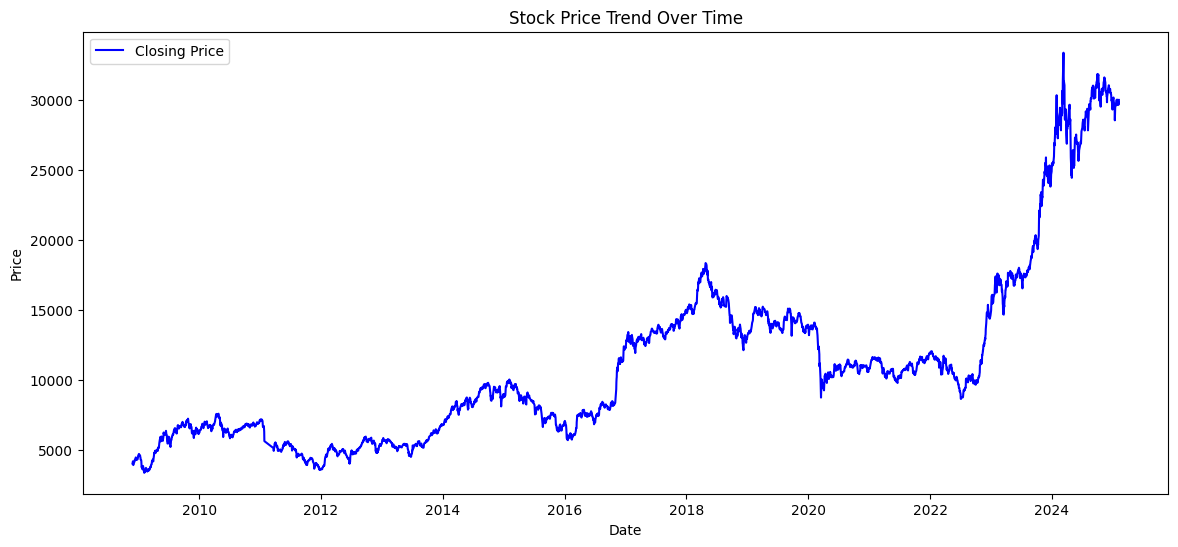

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Price"], label="Closing Price", color="blue")
plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Seasonal Decomposition on Daily Data


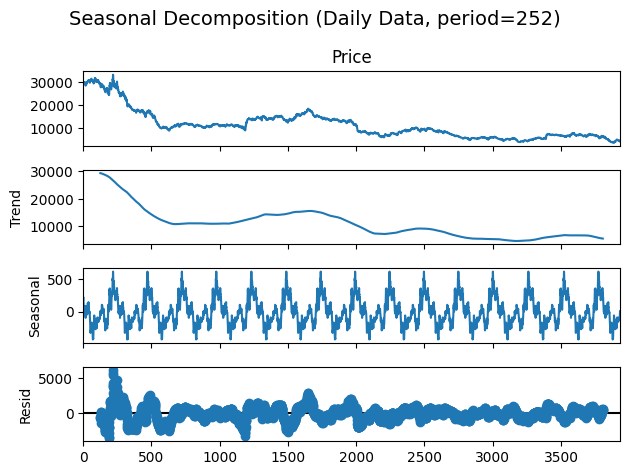

In [20]:
decompose_result = seasonal_decompose(df["Price"], model='additive', period=252)
decompose_result.plot()
plt.suptitle("Seasonal Decomposition (Daily Data, period=252)", fontsize=14)
plt.tight_layout()
plt.show()

## Weekly Decomposition


In [21]:
df_weekly = df.resample("W", on="Date").mean().reset_index()

#  Decompose the weekly time series
df_weekly_for_decomp = df_weekly.copy()
df_weekly_for_decomp.index = pd.DatetimeIndex(df_weekly_for_decomp["Date"])


df_weekly_for_decomp["Price"] = df_weekly_for_decomp["Price"].ffill()

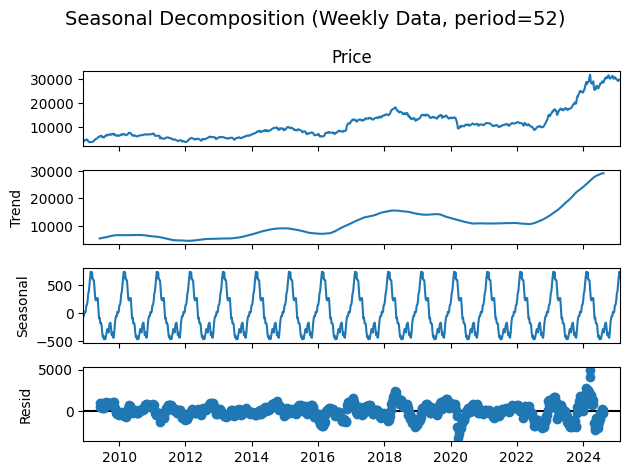

In [22]:

result_weekly = seasonal_decompose(df_weekly_for_decomp["Price"], model='additive', period=52)
result_weekly.plot()
plt.suptitle("Seasonal Decomposition (Weekly Data, period=52)", fontsize=14)
plt.tight_layout()
plt.show()

## Monthly Decomposition


In [23]:
df_monthly = df.resample("M", on="Date").mean().reset_index()

df_monthly_for_decomp = df_monthly.copy()
df_monthly_for_decomp.index = pd.DatetimeIndex(df_monthly_for_decomp["Date"])

df_monthly_for_decomp["Price"] = df_monthly_for_decomp["Price"].ffill()

C:\Users\ziadh\AppData\Local\Temp\ipykernel_11544\2092083349.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M", on="Date").mean().reset_index()


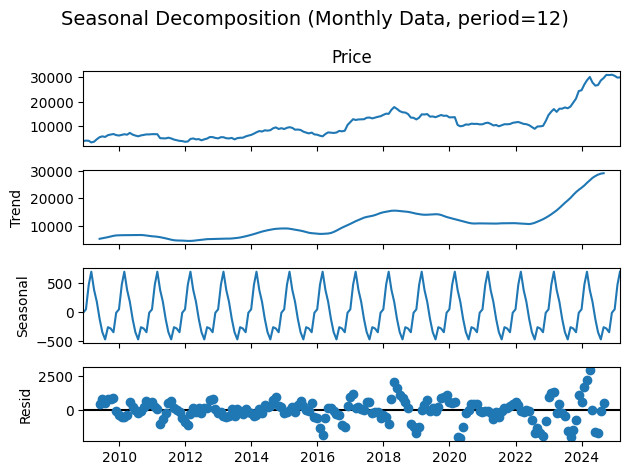

In [24]:
result_monthly = seasonal_decompose(df_monthly_for_decomp["Price"], model='additive', period=12)
result_monthly.plot()
plt.suptitle("Seasonal Decomposition (Monthly Data, period=12)", fontsize=14)
plt.tight_layout()
plt.show()

## Correlation analysis


In [25]:
numerical_features= df.select_dtypes(include=['float64']).copy()

In [26]:
corr_matrix = numerical_features.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
             Price      Open      High       Low      Vol.  Change %
Price     1.000000  0.999584  0.999791  0.999822  0.324710  0.021563
Open      0.999584  1.000000  0.999832  0.999763  0.322699 -0.000454
High      0.999791  0.999832  1.000000  0.999714  0.325433  0.009742
Low       0.999822  0.999763  0.999714  1.000000  0.322570  0.011856
Vol.      0.324710  0.322699  0.325433  0.322570  1.000000  0.118769
Change %  0.021563 -0.000454  0.009742  0.011856  0.118769  1.000000


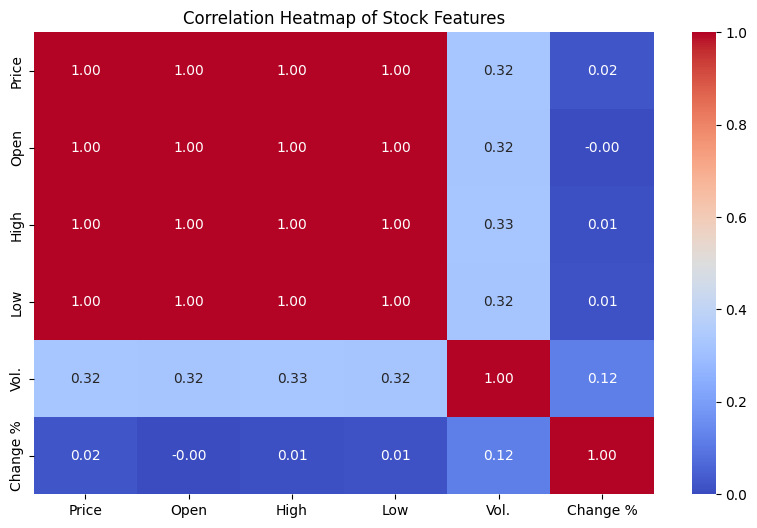

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Stock Features")
plt.show()

## Feature Engineering


### Moving Averages


In [28]:
df['MA7'] = df['Price'].rolling(window=7).mean()
df['MA30'] = df['Price'].rolling(window=30).mean()

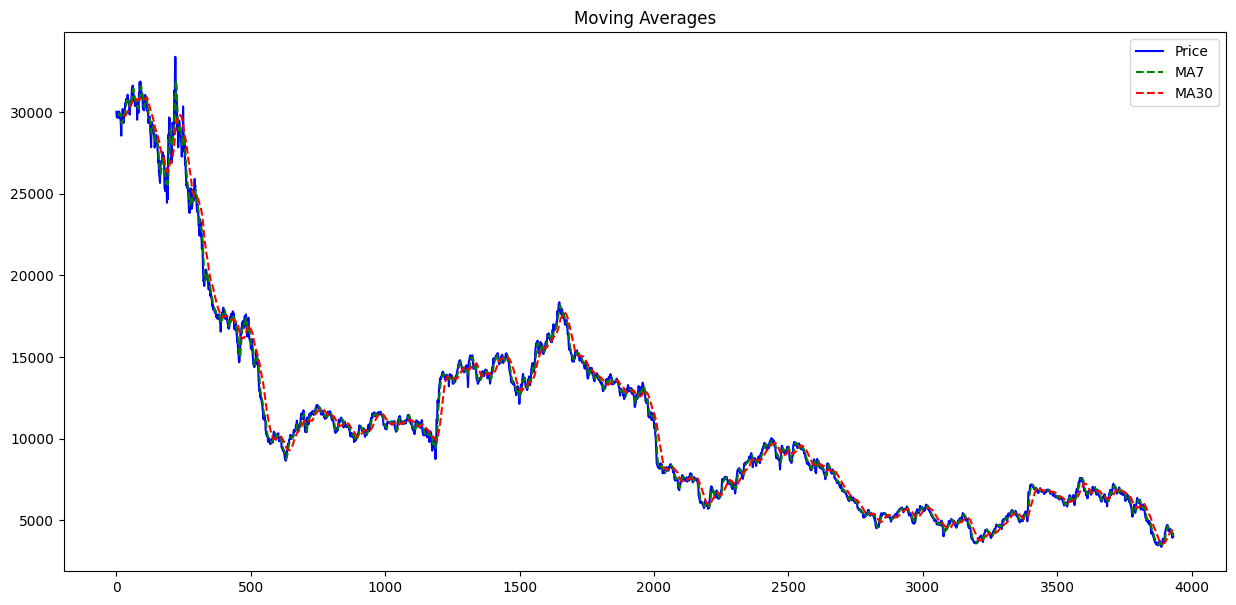

In [29]:
plt.figure(figsize=(15,7))
plt.plot(df['Price'], label='Price', color='blue')
plt.plot(df['MA7'], label='MA7', linestyle='dashed', color='green')
plt.plot(df['MA30'], label='MA30', linestyle='dashed', color='red')
plt.legend()
plt.title('Moving Averages')
plt.show()


**MA7** (7-day) (green line) tracks the Price closely, reacting more quickly to short-term fluctuations. You can see that it moves almost in sync with the Price, but with slightly smoother peaks and troughs.

**MA30** (30-day) (red, dashed line) is smoother and lags behind the immediate price changes. It captures a more medium-term trend, filtering out much of the short-term volatility.


Given the overall decline in Price, both MAs confirm a sustained downward movement, though the 7-day MA shows smaller wiggles along the way.

This can be indicative of a prolonged bear market in the period captured by the data, with short rallies that don’t significantly alter the longer downward trend.


### Daily Return


In [30]:
df["Daily Return"] = df["Price"].pct_change()

In [31]:
df["Daily Range"] = df["High"] - df["Low"]

In [32]:
df["Price Change"] = df["Price"] - df["Open"]

### Rolling Volatility


In [33]:
df["Volatility"] = df["Daily Return"].rolling(window=7).std()

<Figure size 1400x1000 with 0 Axes>

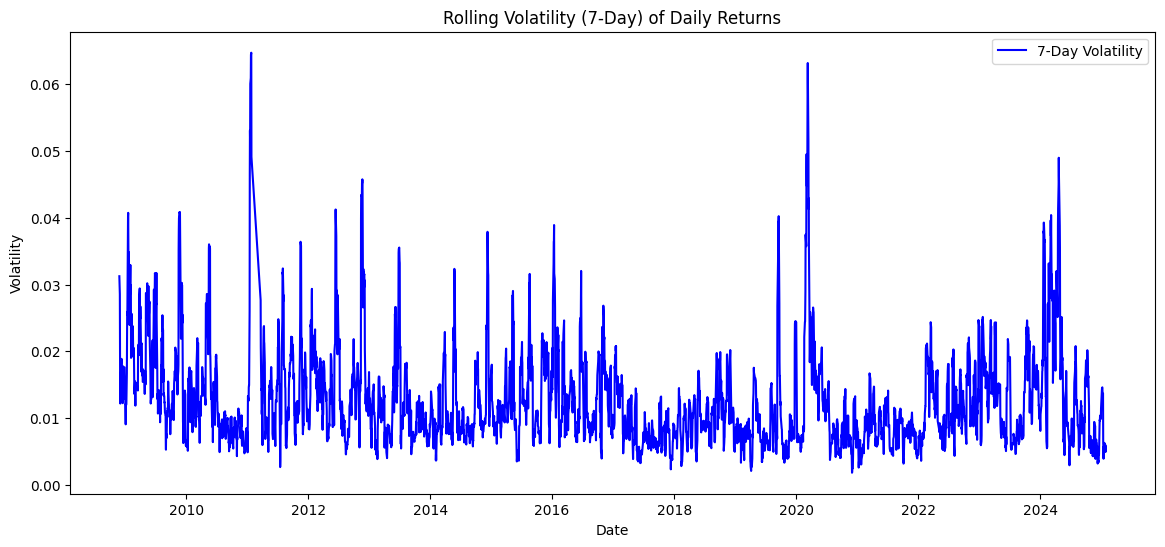

In [34]:
plt.figure(figsize=(14, 10))
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Volatility"], label="7-Day Volatility", color="blue")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Rolling Volatility (7-Day) of Daily Returns")
plt.legend()
plt.show()

**Spiky Periods**:

- The chart shows multiple volatility spikes—some reaching above 0.04–0.06 (or 4–6% in daily return standard deviation).
- These spikes could be linked to major news events, economic crises, currency devaluations, or political changes that caused rapid price swings.

**Quiet Periods**:

- Between spikes, volatility often settles below 0.01–0.02.
- Low volatility suggests more stable or less reactive market conditions over those weeks.


### Relative Strength Index (RSI)


In [35]:
def compute_rsi(df, column='Price', window=14):
    delta = df[column].diff(1)  # Calculate the price change

    gain = delta.where(delta > 0, 0)  # Keep gains, replace losses with 0
    loss = -delta.where(delta < 0, 0)  # Keep losses, replace gains with 0

    avg_gain = gain.rolling(window=window, min_periods=window).mean()  # Average gain over 14 days
    avg_loss = loss.rolling(window=window, min_periods=window).mean()  # Average loss over 14 days

    rs = avg_gain / avg_loss.replace(0, np.nan) # Relative Strength (RS)
    rsi = 100 - (100 / (1 + rs))  # RSI Calculation

    df['RSI'] = rsi  # Add RSI to DataFrame
    return df

# Apply RSI function to DataFrame
df = compute_rsi(df)

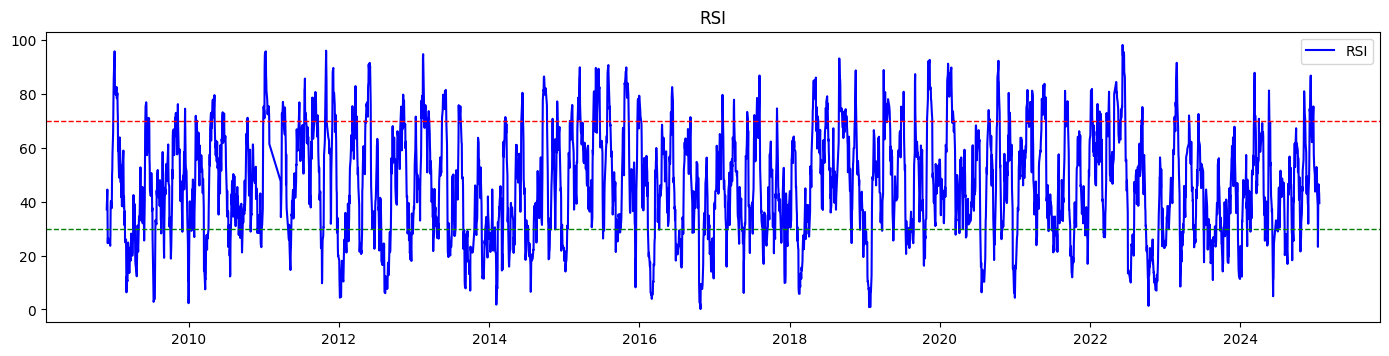

In [36]:
plt.figure(figsize=(14, 10))
plt.subplot(3, 1, 3)
plt.plot(df["Date"], df["RSI"], label="RSI", color="blue")
plt.axhline(70, color="red", linestyle="--", linewidth=1)
plt.axhline(30, color="green", linestyle="--", linewidth=1)
plt.title("RSI")
plt.legend()

plt.tight_layout()
plt.show()


**Above 70–80** (red line ) often suggests overbought conditions.

**Below 20–30** (green line) often suggests oversold conditions.


The RSI is highly active, indicating frequent shifts in momentum.

Overbought and oversold zones are reached regularly, suggesting either a short calculation period or a very volatile market.


### Moving Average Convergence Divergence (MACD)


In [37]:
df["MACD"] = ta.trend.MACD(df["Price"]).macd()

In [38]:
df["Signal Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

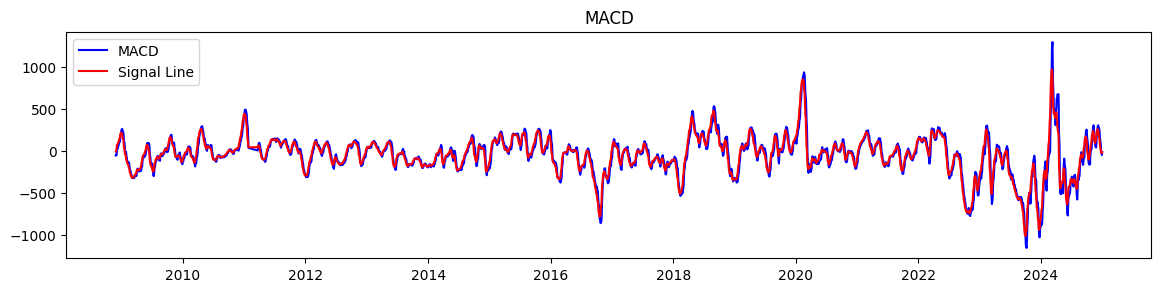

In [39]:
plt.figure(figsize=(14, 10))
plt.subplot(3, 1, 2)
plt.plot(df["Date"], df["MACD"], label="MACD", color="blue")
plt.plot(df["Date"], df["Signal Line"], label="Signal Line", color="red")
plt.title("MACD")
plt.legend()

**Frequent Crossovers**

- The blue and red lines cross multiple times, suggesting frequent momentum changes.
- Each crossover can be interpreted as a shift in short-term vs. long-term momentum.

**Large Swings**

- Notable spikes occur around 2016, 2020, and 2024, with the MACD moving above or below ±500–1000.
- These spikes indicate strong bullish or bearish momentum, likely tied to major price moves or market events.

**Periods Near Zero**

- There are intervals where MACD and the Signal Line hover near zero, suggesting relatively balanced momentum or a sideways market.


### Bollinger Bands


In [40]:
bb = ta.volatility.BollingerBands(df["Price"], window=20)
df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()

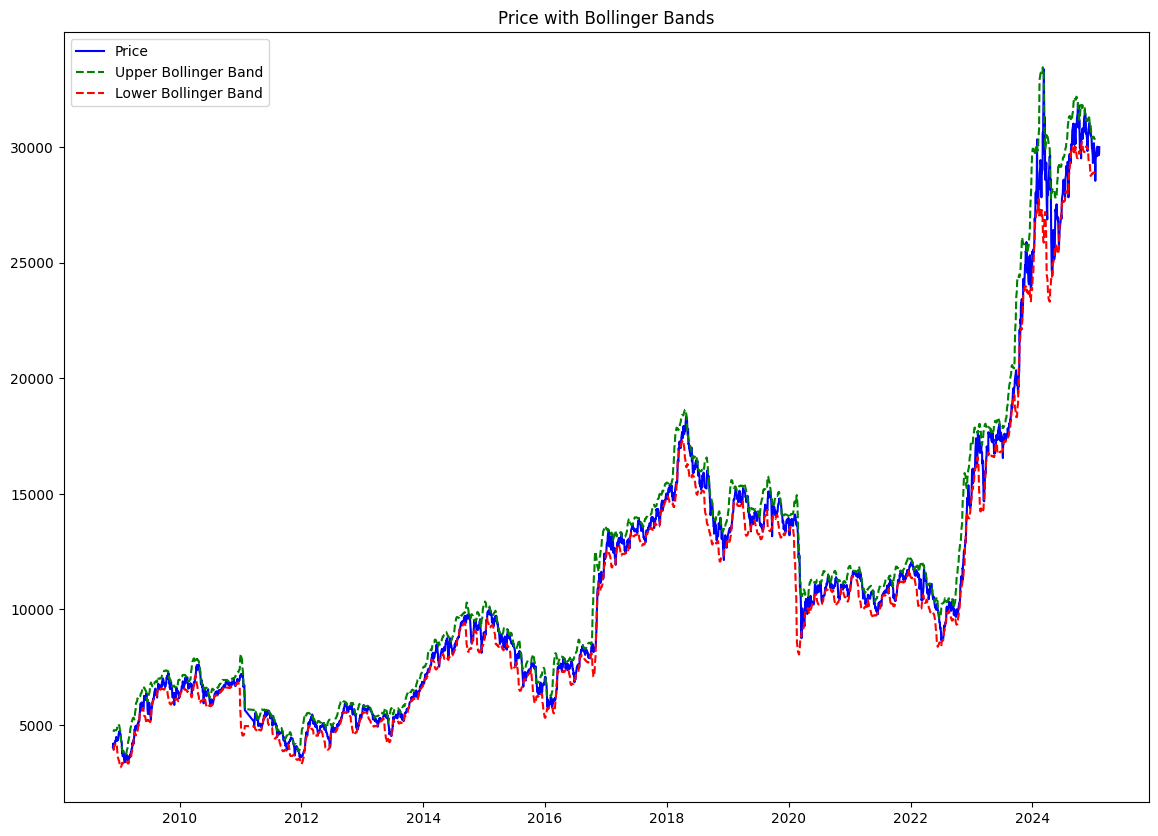

In [41]:
plt.figure(figsize=(14, 10))
plt.plot(df["Date"], df["Price"], label="Price", color="blue")
plt.plot(df["Date"], df["BB_High"], label="Upper Bollinger Band", linestyle="--", color="green")
plt.plot(df["Date"], df["BB_Low"], label="Lower Bollinger Band", linestyle="--", color="red")
plt.title("Price with Bollinger Bands")
plt.legend()


Upper Band (green, dotted) and Lower Band (red, dotted) typically lie ±2 standard deviations from a 20-day moving average (the middle band).

They expand when volatility (standard deviation) increases and contract when volatility decreases.


**Long-Term Uptrend**
The chart shows a steady rise from below 5,000 in early years (2008–2010) to over 30,000 by 2024–2025.
Notably, there’s an accelerated climb from around 2020 onward.

**Periods of High Volatility**
When the price surges sharply (e.g., 2020–2025), the bands widen significantly, reflecting larger price swings.
Around major price peaks, the upper band is far above the middle band, indicating increased volatility.

**Band Touches and Mean Reversion**
During strong uptrends, the price can stay near the upper band for extended periods, suggesting bullish momentum.
When price touches or crosses below the lower band, it may signal oversold conditions or a downward correction.


**The chart confirms a strong long-term uptrend with phases of high volatility, especially post-2020.**


### Quarter of the Year


In [42]:
df["Quarter"] = df["Date"].dt.quarter

C:\Users\ziadh\AppData\Local\Temp\ipykernel_11544\3232626307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarter_counts.index, y=quarter_counts.values, palette="Paired")


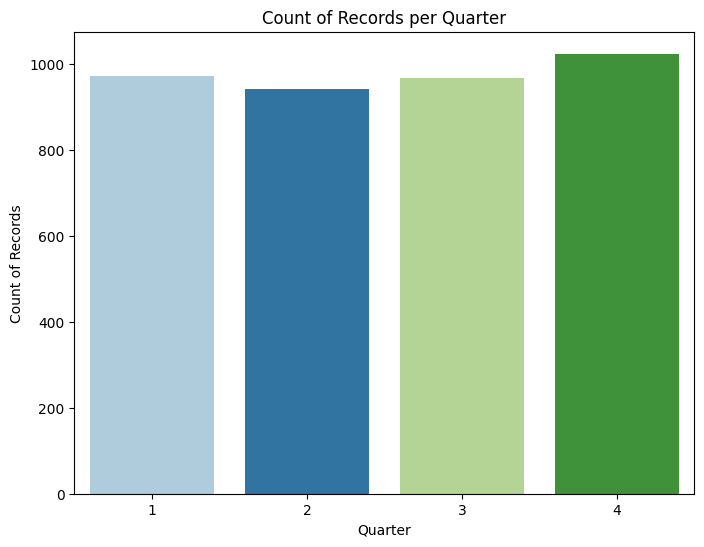

In [43]:
plt.figure(figsize=(8, 6))
quarter_counts = df["Quarter"].value_counts().sort_index()
sns.barplot(x=quarter_counts.index, y=quarter_counts.values, palette="Paired")
plt.xlabel("Quarter")
plt.ylabel("Count of Records")
plt.title("Count of Records per Quarter")
plt.show()


Each quarter has roughly 900–1000 records, indicating the dataset is fairly balanced across Q1, Q2, Q3, and Q4.

The dataset may include partial-year data that skews toward Q4.


C:\Users\ziadh\AppData\Local\Temp\ipykernel_11544\3761644068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Quarter", y="Price", data=df, palette="Paired")


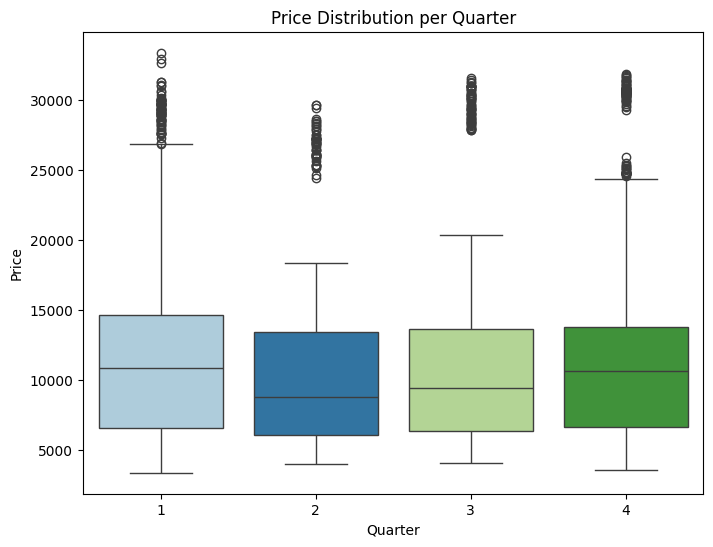

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Quarter", y="Price", data=df, palette="Paired")
plt.xlabel("Quarter")
plt.ylabel("Price")
plt.title("Price Distribution per Quarter")
plt.show()

Q2 shows a lower median price, raising questions about potential seasonal dips or partial data coverage.

The presence of outliers in all quarters indicates significant price spikes at various times, not confined to any single quarter.


### Average True Range (ATR)


In [45]:
df["Previous_Close"] = df["Price"].shift(1)

df["High_Low"] = df["High"] - df["Low"]
df["High_PC"] = (df["High"] - df["Previous_Close"]).abs()  
df["Low_PC"] = (df["Low"] - df["Previous_Close"]).abs()    

df["TR"] = df[["High_Low", "High_PC", "Low_PC"]].max(axis=1)

**High_Low**: The difference between the current day’s high and low.

**High_PC**: The absolute difference between the current day’s high and the previous day’s close.

**Low_PC**: The absolute difference between the current day’s low and the previous day’s close.

**The TR** is then the maximum of these three values for each day.


In [46]:
window = 14
df["ATR"] = df["TR"].rolling(window=window, min_periods=window).mean()

In [47]:
print(df[["Date", "Price", "High", "Low", "Previous_Close", "TR", "ATR"]].tail(20))

           Date    Price     High      Low  Previous_Close      TR         ATR
3913 2008-12-30  4487.47  4488.82  4351.39         4596.49  245.10  180.637143
3914 2008-12-28  4351.39  4358.27  4320.50         4487.47  166.97  161.216429
3915 2008-12-25  4357.96  4400.92  4331.88         4351.39   69.04  141.167143
3916 2008-12-24  4331.88  4411.78  4271.82         4357.96  139.96  141.497143
3917 2008-12-23  4324.27  4361.91  4324.23         4331.88   37.68  131.569286
3918 2008-12-22  4351.38  4386.83  4312.38         4324.27   74.45  120.160000
3919 2008-12-21  4325.77  4453.40  4325.65         4351.38  127.75  120.485714
3920 2008-12-18  4453.40  4516.73  4453.29         4325.77  190.96  124.678571
3921 2008-12-17  4484.01  4509.07  4434.97         4453.40   74.10  125.862143
3922 2008-12-16  4434.97  4450.81  4366.68         4484.01  117.33  127.942143
3923 2008-12-15  4366.68  4366.68  4291.37         4434.97  143.60  127.144286
3924 2008-12-14  4302.03  4329.45  4290.77         4

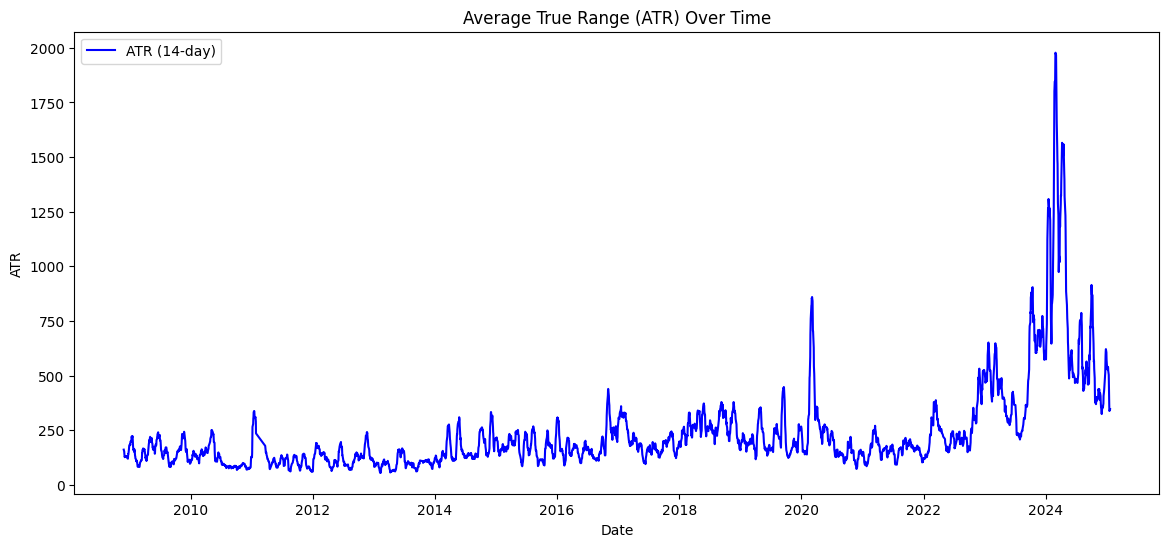

In [48]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["ATR"], label="ATR (14-day)", color="blue")
plt.xlabel("Date")
plt.ylabel("ATR")
plt.title("Average True Range (ATR) Over Time")
plt.legend()
plt.show()

**Relatively Low ATR (2008–2020)**
From 2008 through much of the early 2010s, the ATR remains below 200–300, indicating relatively lower volatility compared to later years.

**Significant Increase (2020–2025)**
Post-2020, the ATR shows sizable and frequent spikes, with peaks surpassing 500–1000, and at one point reaching around 2000.


Long-Term Perspective: The market was relatively less volatile before 2020, with dramatic volatility spikes in the 2023–2024 period.


### Stochastic Oscillator


In [49]:
k_period = 14  # Look-back period for %K
d_period = 3   # Moving average period for %D

In [50]:
df['Lowest_Low'] = df['Low'].rolling(window=k_period).min()
df['Highest_High'] = df['High'].rolling(window=k_period).max()

In [51]:
df['%K'] = 100 * ((df['Price'] - df['Lowest_Low']) / (df['Highest_High'] - df['Lowest_Low']))

In [52]:
df['%D'] = df['%K'].rolling(window=d_period).mean()

In [53]:
print(df[["Date", "Price", "Lowest_Low", "Highest_High", "%K", "%D"]].tail(10))

           Date    Price  Lowest_Low  Highest_High         %K         %D
3923 2008-12-15  4366.68     4271.82       4745.76  20.015192  30.857100
3924 2008-12-14  4302.03     4271.82       4719.22   6.752347  19.435229
3925 2008-12-11  4319.74     4192.16       4621.72  29.700158  18.822566
3926 2008-12-10  4202.25     4059.08       4516.73  31.283732  22.578746
3927 2008-12-04  4059.08     3969.34       4516.73  16.394161  25.792684
3928 2008-12-03  3979.71     3969.34       4516.73   1.894445  16.524113
3929 2008-12-02  3937.66     3829.44       4516.73  15.745901  11.344835
3930 2008-12-01  4022.58     3829.44       4516.73  28.101675  15.247340
3931 2008-11-30  4205.86     3829.44       4516.73  54.768729  32.872102
3932 2008-11-27  4043.72     3829.44       4516.73  31.177523  38.015976


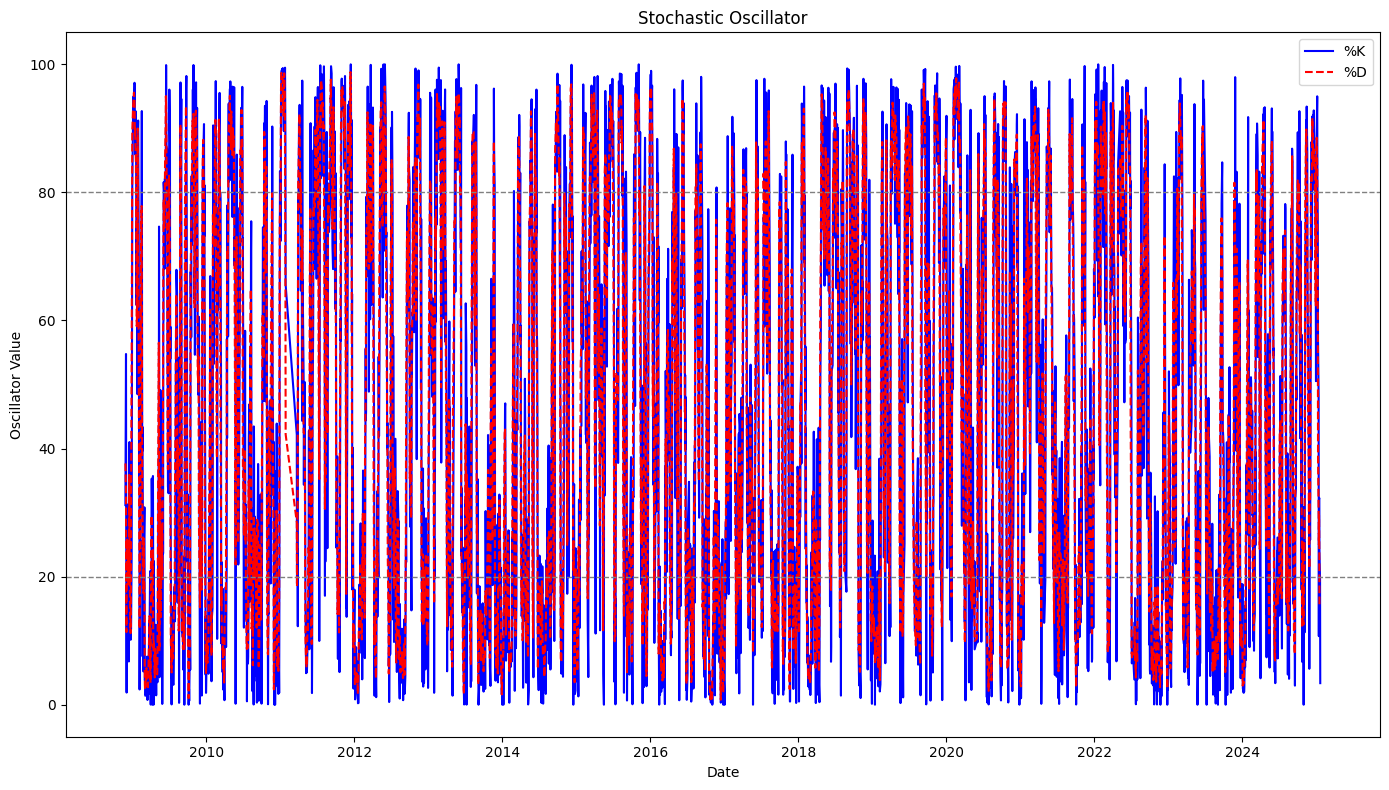

In [54]:
plt.figure(figsize=(14, 8))


plt.plot(df["Date"], df["%K"], label="%K", color="blue")
plt.plot(df["Date"], df["%D"], label="%D", color="red", linestyle="--")


plt.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.axhline(20, color="gray", linestyle="--", linewidth=1)

plt.title("Stochastic Oscillator")
plt.xlabel("Date")
plt.ylabel("Oscillator Value")
plt.legend()
plt.tight_layout()
plt.show()

Above 80 typically indicating overbought conditions.
Below 20 typically indicating oversold conditions.


**Frequent Spikes**

The oscillator oscillates rapidly between 0 and 100, suggesting either a very short lookback period (like 14 days for %K) or a highly volatile market—or both.

The lines (%K and %D) crisscross frequently, generating many potential overbought/oversold signals.

**No Extended Flat Regions**

The plot shows the oscillator rarely stays pinned at the top or bottom for long. Instead, it quickly reverts, indicating constant shifts in momentum.

**Volatile Environment**

When prices are volatile or the time period for the Stochastic calculation is short, the oscillator can produce frequent whipsaws, requiring additional confirmation from other indicators or higher smoothing.


**The Stochastic Oscillator is highly active**


### Correlation analysis


In [55]:
numerical_features= df.select_dtypes(include=['float64']).copy()

In [56]:
corr_matrix = numerical_features.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                   Price      Open      High       Low      Vol.  Change %  \
Price           1.000000  0.999584  0.999791  0.999822  0.324710  0.021563   
Open            0.999584  1.000000  0.999832  0.999763  0.322699 -0.000454   
High            0.999791  0.999832  1.000000  0.999714  0.325433  0.009742   
Low             0.999822  0.999763  0.999714  1.000000  0.322570  0.011856   
Vol.            0.324710  0.322699  0.325433  0.322570  1.000000  0.118769   
Change %        0.021563 -0.000454  0.009742  0.011856  0.118769  1.000000   
MA7             0.999041  0.998558  0.998815  0.998821  0.329991  0.025277   
MA30            0.995090  0.994606  0.994899  0.994808  0.352835  0.028115   
Daily Return    0.001981  0.005105  0.003671  0.004250 -0.048134 -0.176239   
Daily Range     0.625442  0.628694  0.635807  0.617182  0.296387 -0.062209   
Price Change    0.053460  0.024632  0.037620  0.041079  0.082284  0.763009   
Volatility     -0.086004 -0.083917 -0.080641

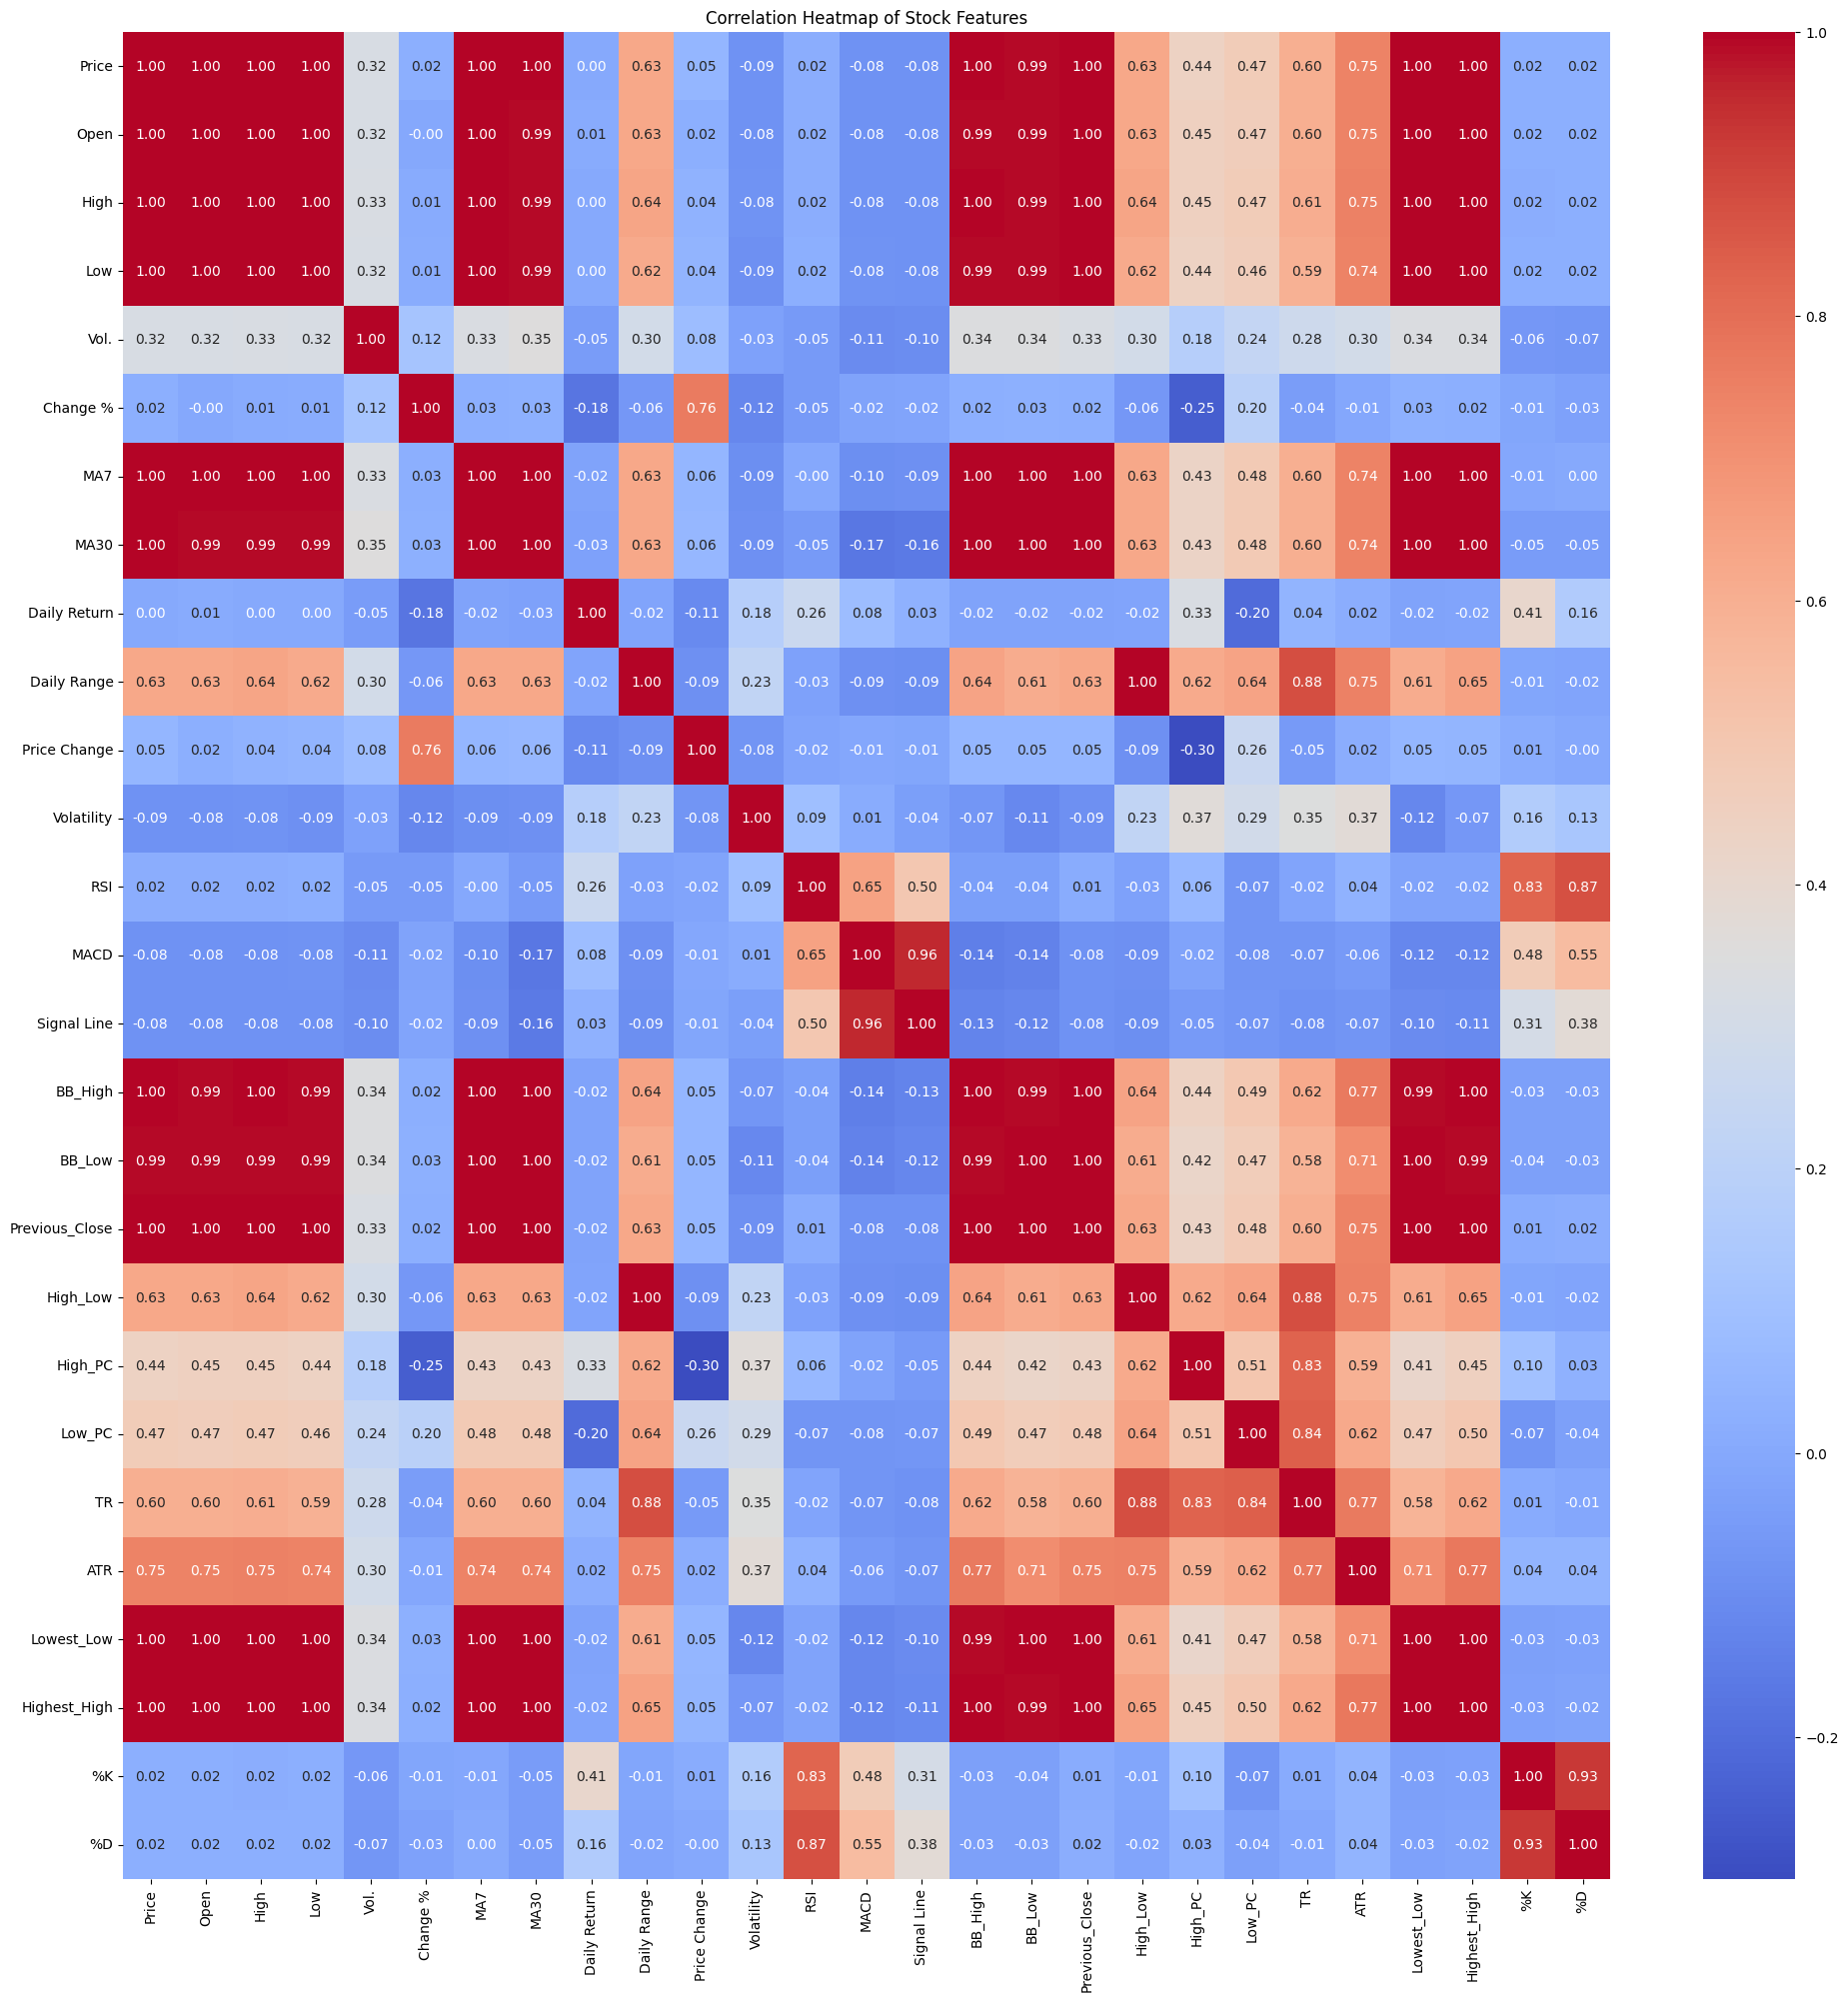

In [57]:
plt.figure(figsize=(24, 24))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Stock Features")
plt.show()

#### **Strongly Correlated Groups**


**Price, Open, High, Low, Previous_Close, MA7, MA30, BB_High, BB_Low, Highest_High, Lowest_Low**

- All are above 0.99 with each other, which means they essentially carry the same price information in different forms.


**Daily Range, TR, ATR, High_Low, High_PC, Low_PC**

These columns measure intraday or rolling volatility in various ways:

- Daily Range ≈ High – Low
- TR (True Range) ≈ max of (High_Low, High_PC, Low_PC)
- ATR is the rolling average of TR, leading to strong correlation.


**RSI, %K, and %D**

- The Stochastic Oscillator lines are highly correlated with each other (0.93).
- RSI also has a high correlation (0.83+) with %K and %D.


**MACD and Signal Line**

- Naturally correlated (both are derived from EMAs of Price).
- Show moderate correlation with RSI/Stochastic (0.30–0.55 range).


#### **Notable Individual Correlations**


**Volume (Vol.)**

- Moderately correlated with Price (~0.32).
- Correlation with volatility measures (ATR, TR) is lower (~0.28).


**Change % vs. Price Change**

- Change % (percentage change) and Price Change (absolute difference) have a strong correlation (~0.76), but each tells a different story:
  - Change % normalizes the price move by the previous close.
  - Price Change is the absolute difference (in points).


**Daily Return**

- Weak correlation with most price features (±0.02 to ±0.01 range).
- Some moderate relationships with volatility measures (e.g., High_PC at ~0.33).


### Feature Selection


**Price (closing price)** (Trend/Level).

**Volume (Vol.)** (Market Participation) is only moderately correlated with price and can reveal liquidity/participation info.

**ATR** (Volatility) is a rolling measure of True Range, and typically more robust for modeling.

**RSI** (Momentum) is a classic overbought/oversold measure.

**MACD** (Momentum) captures momentum shifts between short/long EMAs.

**Daily Return (or Change %)** (Short-Term Change).


In [58]:
selected_features = ["Date", "Price", "Vol.", "ATR", "RSI", "MACD", "Daily Return"]

stock = df[selected_features].copy()


In [59]:
print("Missing Values:\n", stock.isnull().sum())

Missing Values:
 Date             0
Price            0
Vol.             0
ATR             13
RSI             13
MACD            25
Daily Return     1
dtype: int64


In [60]:
stock.dropna(inplace=True)

In [61]:
stock.head()

,Date,Price,Vol.,ATR,RSI,MACD,Daily Return
25,2024-12-31,29740.58,102620000.0,563.995714,46.786344,-13.642200,-0.010642
26,2024-12-30,29325.20,97650000.0,573.322143,43.692508,-43.940238,-0.013967
27,2024-12-29,29594.48,71230000.0,606.342143,49.691446,-45.696247,0.009183
28,2024-12-26,29957.97,53510000.0,621.321429,52.672670,-17.554930,0.012282
29,2024-12-25,30005.00,90650000.0,611.752857,54.744233,8.444848,0.001570


In [62]:
df.dropna(inplace=True)

In [63]:
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA30,Daily Return,...,Previous_Close,High_Low,High_PC,Low_PC,TR,ATR,Lowest_Low,Highest_High,%K,%D
29,2024-12-25,30005.00,29973.15,30164.71,29973.15,90650000.0,0.0011,29838.188571,29712.974333,0.001570,...,29957.97,191.56,206.74,15.18,206.74,611.752857,28349.98,30279.95,85.753665,77.851124
30,2024-12-24,29973.15,30118.38,30165.45,29810.40,64740000.0,-0.0048,29808.122857,29711.684667,-0.001061,...,30005.00,355.05,160.45,194.60,355.05,591.540000,28349.98,30279.95,84.103380,84.391295
31,2024-12-23,30118.38,30372.70,30443.89,30118.38,88370000.0,-0.0084,29816.394286,29724.444333,0.004845,...,29973.15,325.51,470.74,145.23,470.74,550.882143,28556.28,30443.89,82.755442,84.204162
32,2024-12-22,30372.70,30526.71,30626.63,30372.70,49700000.0,-0.0050,29906.697143,29747.918667,0.008444,...,30118.38,253.93,508.25,254.32,508.25,513.533571,28969.26,30626.63,84.678738,83.845853
33,2024-12-19,30526.71,30503.07,30528.42,30211.82,94120000.0,0.0008,30078.341429,29773.650000,0.005071,...,30372.70,316.60,155.72,160.88,316.60,472.692857,29237.94,30626.63,92.804730,86.746303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3928,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107,4237.780000,4379.042667,-0.019554,...,4059.08,106.20,26.83,79.37,106.20,127.019286,3969.34,4516.73,1.894445,16.524113
3929,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211,4166.735714,4384.285333,-0.010566,...,3979.71,108.22,42.05,150.27,150.27,132.821429,3829.44,4516.73,15.745901,11.344835
3930,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436,4117.578571,4384.326000,0.021566,...,3937.66,163.01,247.93,84.92,247.93,140.533571,3829.44,4516.73,28.101675,15.247340
3931,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401,4103.840000,4383.880000,0.045563,...,4022.58,127.79,205.50,77.71,205.50,152.520714,3829.44,4516.73,54.768729,32.872102


# LSTM


Epoch 1/150
97/97 [==============================] - 8s 20ms/step - loss: 0.0031 - val_loss: 5.4522e-05
Epoch 2/150
97/97 [==============================] - 1s 10ms/step - loss: 4.3179e-04 - val_loss: 5.7112e-05
Epoch 3/150
97/97 [==============================] - 1s 10ms/step - loss: 3.9194e-04 - val_loss: 4.7594e-05
Epoch 4/150
97/97 [==============================] - 1s 11ms/step - loss: 3.4992e-04 - val_loss: 4.1479e-05
Epoch 5/150
97/97 [==============================] - 1s 10ms/step - loss: 2.7305e-04 - val_loss: 2.9967e-05
Epoch 6/150
97/97 [==============================] - 1s 10ms/step - loss: 3.0398e-04 - val_loss: 2.6558e-05
Epoch 7/150
97/97 [==============================] - 1s 10ms/step - loss: 2.4348e-04 - val_loss: 4.4303e-05
Epoch 8/150
97/97 [==============================] - 1s 10ms/step - loss: 2.5264e-04 - val_loss: 3.1170e-05
Epoch 9/150
97/97 [==============================] - 1s 10ms/step - loss: 2.1987e-04 - val_loss: 3.1641e-05
Epoch 10/150
97/97 [============

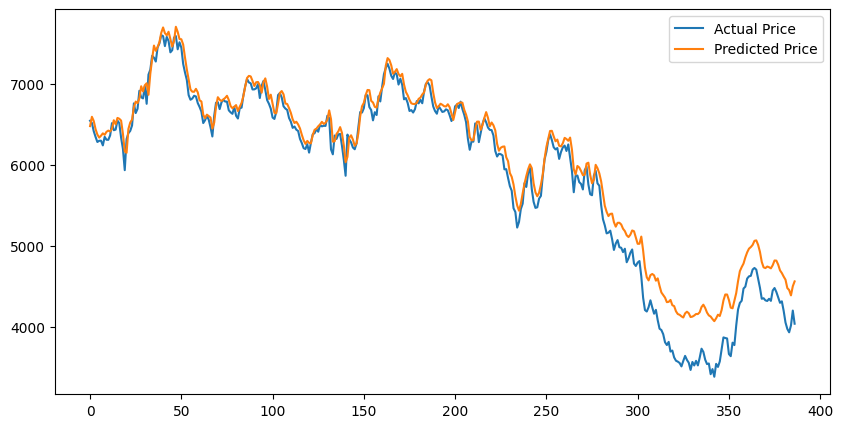

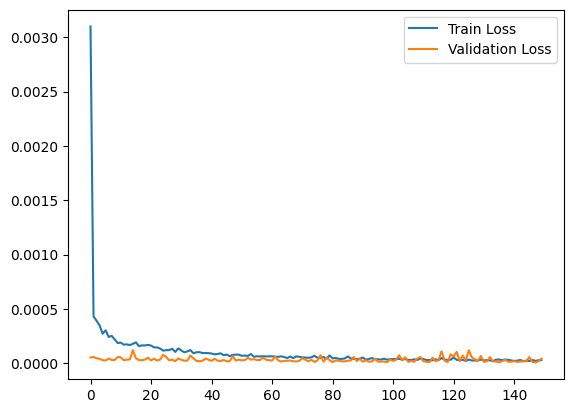

In [64]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.optimizers import Adam

# Load dataset (Assuming 'df' is already loaded)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# Select features and target
features = ["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]
target = "Price"

data = df[features]
price = df[[target]]

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
price_scaler = MinMaxScaler()
price_scaled = price_scaler.fit_transform(price)

# Create sequences
def create_sequences(data, target, seq_length=15):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 15
X, y = create_sequences(data_scaled, price_scaled, seq_length)

# Split into train, validation, test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Build LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, len(features))),
    Dropout(0.1), # Drop 30% of neurons in this layer
    LSTM(64, return_sequences=False),
    Dropout(0.1), # Drop 30% of neurons again
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss=tf.keras.losses.Huber(delta=1.0))

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=150, batch_size=32)

# Predict on test data
predicted_price = model.predict(X_test)
predicted_price = price_scaler.inverse_transform(predicted_price)
y_test_actual = price_scaler.inverse_transform(y_test.reshape(-1, 1))

# Predict on training data (for training accuracy)
y_train_pred = model.predict(X_train)
y_train_actual = price_scaler.inverse_transform(y_train.reshape(-1, 1))
y_train_pred_actual = price_scaler.inverse_transform(y_train_pred)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual, predicted_price)
mse = mean_squared_error(y_test_actual, predicted_price)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test_actual, predicted_price)
test_accuracy = r2_test * 100  # Convert to percentage

# Calculate training accuracy
r2_train = r2_score(y_train_actual, y_train_pred_actual)
train_accuracy = r2_train * 100  # Convert to percentage

# Print results
print(f"Training Accuracy (R² Score): {train_accuracy:.2f}%")
print(f"Test Accuracy (R² Score): {test_accuracy:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predicted_price, label='Predicted Price')
plt.legend()
plt.show()

# Loss Curve
plt.plot(history.history['loss'], label='Train Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.legend()
plt.show()


In [65]:
print(f"Training Accuracy (R² Score): {train_accuracy:.2f}%")

Training Accuracy (R² Score): 99.06%


In [66]:
print(f"Test Accuracy (R² Score): {test_accuracy:.2f}%")

Test Accuracy (R² Score): 94.73%


In [67]:
def predict_next_7_days(model, last_sequence, scaler, seq_length=30):
    """
    Predicts the next 7 days using the trained LSTM model.

    Parameters:
    - model: Trained LSTM model.
    - last_sequence: The last available sequence from the dataset (shape: (seq_length, num_features)).
    - scaler: The scaler used for target variable normalization.
    - seq_length: The sequence length used during training.

    Returns:
    - future_predictions: A list of predicted values for the next 7 days.
    """
    future_predictions = []
    current_sequence = last_sequence.copy()  # Start with the last sequence

    for _ in range(7):  # Predict for the next 7 days
        predicted_value = model.predict(current_sequence.reshape(1, seq_length, -1))
        predicted_value = scaler.inverse_transform(predicted_value)[0, 0]  # Rescale back to original value

        future_predictions.append(predicted_value)

        # Update sequence: Remove first element and append new predicted value
        new_sequence = np.roll(current_sequence, shift=-1, axis=0)
        new_sequence[-1, -1] = predicted_value  # Assuming the last feature is the target

        current_sequence = new_sequence

    return future_predictions

# Get the last available sequence from the dataset
last_sequence = X_test[-1]  # Use the last sequence from test data

# Predict the next 7 days
next_7_days = predict_next_7_days(model, last_sequence, price_scaler)

# Print the predictions
print("Predicted Prices for the Next 7 Days:", next_7_days)


1/1 [==============================] - 0s 24ms/step
Predicted Prices for the Next 7 Days: [18305.9, 21876.139, 23745.615, 25230.79, 26226.793, 26862.586, 27265.752]


1/1 [==============================] - 0s 22ms/step
Actual vs Predicted Prices:
Actual vs Predicted Prices:
   Actual Price  Predicted Price  Difference
0      29444.65     29461.650391   17.000391
1      29785.91     29982.408203  196.498203
2      29929.64     30029.929688  100.289688
3      30183.61     30296.685547  113.075547
4      30060.48     30140.644531   80.164531
5      29740.58     29816.164062   75.584062
6      29325.20     29408.847656   83.647656
7      29594.48     29511.275391   83.204609
8      29957.97     29913.486328   44.483672


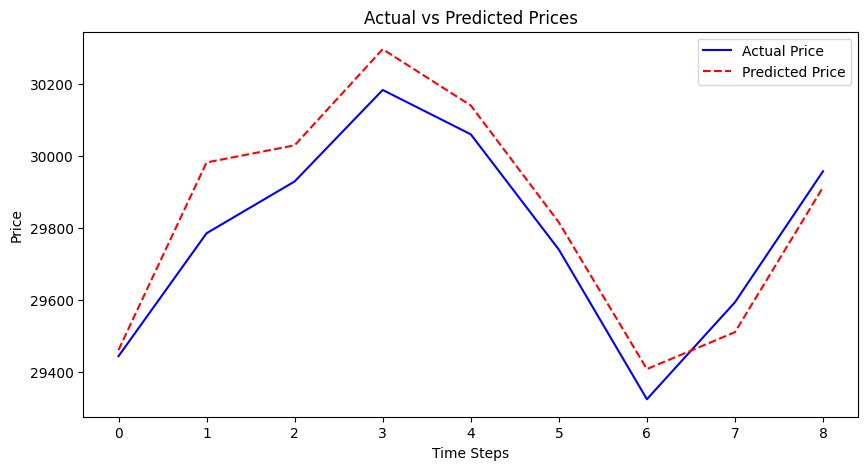

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load new test data
new_df = pd.read_csv("newTest.csv")

# Select features and target
features = ["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]
target = "Price"

data = new_df[features]
price = new_df[[target]]

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
price_scaler = MinMaxScaler()
price_scaled = price_scaler.fit_transform(price)

# Create sequences
def create_sequences(data, target, seq_length=10):
    X_new, y_new = [], []
    for i in range(len(data) - seq_length):
        X_new.append(data[i:i+seq_length])
        y_new.append(target[i+seq_length])
    return np.array(X_new), np.array(y_new)

seq_length = 10
X_new, y_new = create_sequences(data_scaled, price_scaled, seq_length)

# Predict prices
predicted_price_new = model.predict(X_new)

predicted_price_new = price_scaler.inverse_transform(predicted_price_new)
actual_price_new = price_scaler.inverse_transform(y_new.reshape(-1, 1))

print("Actual vs Predicted Prices:")
# Compute the absolute difference
difference = np.abs(actual_price_new.flatten() - predicted_price_new.flatten())

print("Actual vs Predicted Prices:")
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    "Actual Price": actual_price_new.flatten(),
    "Predicted Price": predicted_price_new.flatten(),
    "Difference": difference
})
print(comparison_df.head(20))  

plt.figure(figsize=(10, 5))
plt.plot(actual_price_new, label='Actual Price', color='blue')
plt.plot(predicted_price_new, label='Predicted Price', linestyle='dashed', color='red')
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()


1/1 [==============================] - 0s 22ms/step
Predicted Prices for new data:
[[29461.65 ]
 [29982.408]
 [30029.93 ]
 [30296.686]
 [30140.645]
 [29816.164]
 [29408.848]
 [29511.275]
 [29913.486]]


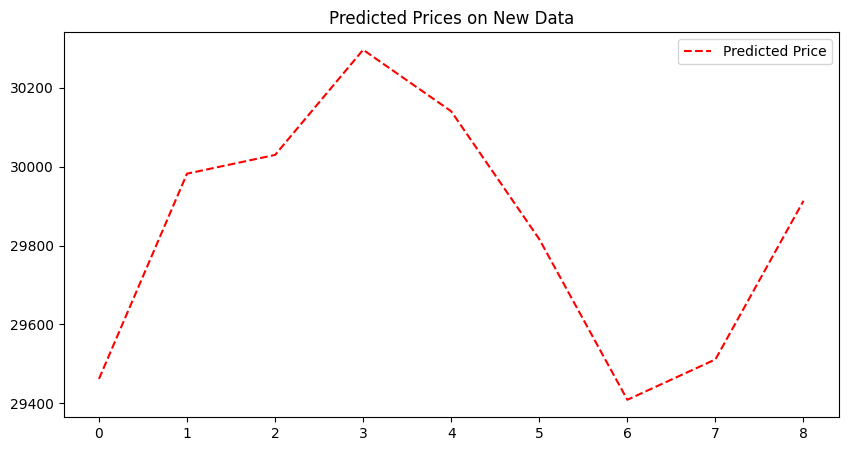

In [69]:
# Load new test data
new_df = pd.read_csv("newTest.csv")

# Select features and target
features = ["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]
target = "Price"

data = new_df[features]
price = new_df[[target]]

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
price_scaler = MinMaxScaler()
price_scaled = price_scaler.fit_transform(price)

# Create sequences
def create_sequences(data, target, seq_length=10):
    X_new, y_new = [], []
    for i in range(len(data) - seq_length):
        X_new.append(data[i:i+seq_length])
        y_new.append(target[i+seq_length])
    return np.array(X_new), np.array(y_new)

seq_length = 10
X_new, y_new = create_sequences(data_scaled, price_scaled, seq_length)

predicted_price_new = model.predict(X_new)

# إرجاع القيم إلى المدى الأصلي باستخدام المحول العكسي
predicted_price_new = price_scaler.inverse_transform(predicted_price_new)

# عرض التوقعات
print("Predicted Prices for new data:")
print(predicted_price_new)

# رسم البيانات الفعلية مقابل التنبؤات
plt.figure(figsize=(10, 5))
plt.plot(predicted_price_new, label='Predicted Price', linestyle='dashed', color='red')
plt.legend()
plt.title("Predicted Prices on New Data")
plt.show()


1/1 [==============================] - 0s 22ms/step
Actual vs Predicted Prices:
    Actual Price  Predicted Price
0       29605.12     29502.435547
1       29389.93     29318.791016
2       28967.09     28946.064453
3       28556.28     28611.511719
4       29277.45     29189.810547
5       29444.65     29426.046875
6       29785.91     29966.080078
7       29929.64     30003.003906
8       30183.61     30274.517578
9       30060.48     30109.853516
10      29740.58     29773.375000
11      29325.20     29346.236328
12      29594.48     29447.294922
13      29957.97     29906.806641


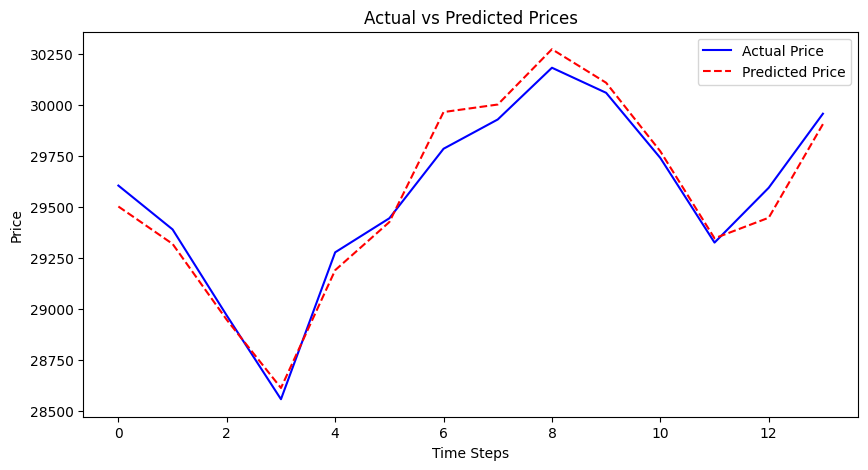

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load new test data
new_df = pd.read_csv("newTest.csv")
# Load dataset (Assuming 'df' is already loaded)
new_df["Date"] = pd.to_datetime(new_df["Date"])
new_df.set_index("Date", inplace=True)

# Select features and target
features = ["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]
target = "Price"

data = new_df[features]
price = new_df[[target]]

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
price_scaler = MinMaxScaler()
price_scaled = price_scaler.fit_transform(price)

# Create sequences
def create_sequences(data, target, seq_length=5):
    X_new, y_new = [], []
    for i in range(len(data) - seq_length):
        X_new.append(data[i:i+seq_length])
        y_new.append(target[i+seq_length])
    return np.array(X_new), np.array(y_new)

seq_length = 5
X_new, y_new = create_sequences(data_scaled, price_scaled, seq_length)

# Predict prices
predicted_price_new = model.predict(X_new)

# إرجاع القيم إلى المدى الأصلي باستخدام المحول العكسي
predicted_price_new = price_scaler.inverse_transform(predicted_price_new)
actual_price_new = price_scaler.inverse_transform(y_new.reshape(-1, 1))

# عرض التوقعات مقابل القيم الفعلية
print("Actual vs Predicted Prices:")
comparison_df = pd.DataFrame({
    "Actual Price": actual_price_new.flatten(),
    "Predicted Price": predicted_price_new.flatten()
})
print(comparison_df.head(20))  # عرض أول 20 صفًا للمقارنة

# رسم البيانات الفعلية مقابل التنبؤات
plt.figure(figsize=(10, 5))
plt.plot(actual_price_new, label='Actual Price', color='blue')
plt.plot(predicted_price_new, label='Predicted Price', linestyle='dashed', color='red')
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()


In [71]:
# # دالة التنبؤ بسعر جديد
# def predict_price(new_input):
#     new_input = np.array(new_input).reshape(1, -1)  # تأكد أن الإدخال في شكل مصفوفة
#     new_input_scaled = scaler.transform(new_input)  # تطبيق نفس مقياس التطبيع
#     new_input_sequence = np.reshape(new_input_scaled, (1, seq_length, len(features)))  # إعادة تشكيل البيانات
#     predicted_price_scaled = model.predict(new_input_sequence)
#     predicted_price = price_scaler.inverse_transform(predicted_price_scaled.reshape(-1, 1))  # عكس التطبيع
#     return predicted_price[0][0]

# # مثال لاستخدام دالة التنبؤ
# new_data = [[29979.14, 30258.34, 29947.05, 71450000, 29891.63571, 30271.06233, 380.3657143,30667.75826, 311.29, 29322.11474]]
# predicted_value = predict_price(new_data)
# print(f"Predicted Price: {predicted_value:.2f}")

In [72]:
# import numpy as np
# import pandas as pd

# # Assume these are already defined from your training pipeline:
# # scaler, price_scaler, seq_length, model, and the list of features

# # Create a DataFrame for your new data.
# # IMPORTANT: Ensure that the new_data has at least 'seq_length' rows.
# # The columns should match the order: ["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]

# # new_data = pd.DataFrame({
# #     "Open": [29979.14],  # 60 values
# #     "High": [30258.34],
# #     "Low": [29947.05],
# #     "Vol.": [71450000],
# #     "MA7": [29891.63571],
# #     "MA30": [30271.06233],
# #     "ATR": [380.3657143],
# #     "BB_High": [30667.75826],
# #     "Daily Range": [311.29],
# #     "BB_Low": [29322.11474]
# # })
# new_data = pd.DataFrame({
#     "Open": [30005],  # 60 values
#     "High": [30039.6],
#     "Low": [29937.24],
#     "Vol.": [53510000],
#     "MA7": [29827.42286],
#     "MA30": [29713.28333],
#     "ATR": [380.3657143],
#     "BB_High": [30436.40811],
#     "Daily Range": [102.36],
#     "BB_Low": [621.3214286]
# })

# # 1. Extract only the features needed and ensure the correct order:
# new_data = new_data[["Open", "High", "Low", "Vol.", "MA7", "MA30", "ATR", "BB_High", "Daily Range", "BB_Low"]]

# # 2. Scale the new input data using the same scaler
# new_data_scaled = scaler.transform(new_data)


# # 3. Reshape data to form a single sequence (since LSTM expects [samples, timesteps, features])
# new_sequence = np.expand_dims(new_data_scaled, axis=0)  # Now shape is (1, 60, num_features)
# # 4. Predict the scaled price using the trained model
# predicted_price_scaled = model.predict(new_sequence)

# # 5. Inverse transform the predicted price to get the original scale
# predicted_price = price_scaler.inverse_transform(predicted_price_scaled)

# print("Predicted Price:", predicted_price[0][0])
